## **Stellar Classification Comparative Analysis**

**Author:** Brian Urban 

**Affiliation:** Jarvis College of Computing and Digital Media, DePaul University

<br>

---

#### **1. Environment Setup and Reproducibility**

This section imports the core Python libraries used in this project:

- `pandas` for loading, exploring and manipulating tabular data.

- `scikit-learn` for preprocessing, dataset splitting, metrics, and baseline models (including ensemble methods: Random Forest and Gradient Boosting).

- `scipy` for paired statistical significance testing (Wilcoxon signed-rank test).

- `matplotlib` and `seaborn` are used to plot training results and evaluation metrics.

- `torch` for implementing and training the neural network model.

In [1]:
# ============================================================
# IMPORTING LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
#import os
import random
#from pathlib import Path
from scipy.stats import wilcoxon
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

All random seeds are fixed for full reproducibility across experiments.

In [2]:
# ============================================================
# SET ALL SEEDS
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

<br>

---

#### **2. Data Pipeline, Model Architecture, and Evaluation Framework**

The preprocessing pipeline separates numeric features (temperature, luminosity, radius, absolute magnitude) from categorical features (star color, spectral class) to enable targeted noise injection on continuous physical observables. Numeric features are standardized within each cross-validation fold to prevent data leakage, while categorical features are one-hot encoded once outside the CV loop, reflecting the assumption that spectral classifications remain reliable even when physical measurements carry uncertainty.

The experiment uses 5-fold stratified cross-validation rather than a single train/validation/test split, providing more reliable performance estimates on the 240-sample dataset. Six models are evaluated: a PyTorch MLP, logistic regression, an unconstrained decision tree, a depth-constrained decision tree (max_depth=4), and two ensemble variants (Random Forest and Gradient Boosting). The ensemble methods were added to investigate whether averaging multiple trees could smooth out the threshold sensitivity characteristic of single decision trees.

The MLP architecture consists of two hidden layers (64 and 32 neurons) with ReLU activations, batch normalization, and dropout(0.3), followed by a 6-neuron output layer. Dropout rates in the range 0.1–0.5 were explored, with 0.3 selected for the primary noise sweep. Subsequent dropout ablation revealed that higher regularization (0.5) achieved marginally better accuracy, demonstrating that aggressive dropout does not necessarily harm generalization on this dataset when principled final-epoch evaluation is employed.

In [3]:
# ============================================================
# LOAD AND PREPARE DATA (modified from original)
# ============================================================

df = pd.read_csv("hr-diagram.csv")
df = df.rename(columns={
    'Temperature (K)':         'Temperature',
    'Luminosity (L/Lo)':       'Luminosity',
    'Radius (R/Ro)':           'Radius',
    'Absolute Magnitude (Mv)': 'Absolute_Magnitude',
    'Star Color':              'Color',
    'Spectral Class':          'Spectral_Class',
    'Star Type':               'Star_Type'
})

# Clean whitespace in categorical columns
df['Color'] = df['Color'].str.strip()

# Separate numeric and categorical features
numeric_cols = ['Temperature', 'Luminosity', 'Radius', 'Absolute_Magnitude']
categorical_cols = ['Color', 'Spectral_Class']

# Raw numeric features as numpy array (targets for noise injection)
X_numeric_raw = df[numeric_cols].values.astype(float)

# One-hot encode ONLY the categorical columns, convert to numpy array
X_categorical = pd.get_dummies(df[categorical_cols]).values.astype(float)

# Target as numpy array
y_array = df['Star_Type'].values

# Sanity check—run this to verify before proceeding
print(f"X_numeric_raw: type={type(X_numeric_raw)}, shape={X_numeric_raw.shape}")
print(f"X_categorical: type={type(X_categorical)}, shape={X_categorical.shape}")
print(f"y_array:       type={type(y_array)}, shape={y_array.shape}")

X_numeric_raw: type=<class 'numpy.ndarray'>, shape=(240, 4)
X_categorical: type=<class 'numpy.ndarray'>, shape=(240, 17)
y_array:       type=<class 'numpy.ndarray'>, shape=(240,)


In [4]:
# ============================================================
# HELPER FUNCTION 1: NOISE INJECTION
# ============================================================

def add_gaussian_noise(X_numeric, noise_level, seed=42):
    """
    Add Gaussian noise proportional to each feature's standard deviation.
    Simulates measurement uncertainty on continuous physical observables.
    noise_level: fraction of feature std (0.1 = 10% of std as noise std)
    """
    rng = np.random.RandomState(seed)
    X_noisy = X_numeric.copy()
    for col in range(X_numeric.shape[1]):
        col_std = X_numeric[:, col].std()
        if col_std > 0:
            noise = rng.normal(0, noise_level * col_std, size=X_numeric.shape[0])
            X_noisy[:, col] += noise
    return X_noisy

In [5]:
# ============================================================
# HELPER FUNCTION 2: MLP TRAIN/EVAL
# ============================================================

def train_eval_mlp(X_train, y_train, X_test, y_test, dropout=0.3,
                   lr=0.001, epochs=50, batch_size=32, seed=42):
    """
    Train a regularized MLP and return (accuracy, macro_f1).
    Default dropout=0.3; ablation study (Section 5) showed 0.5 performed marginally better.
    """
    torch.manual_seed(seed)
    input_dim = X_train.shape[1]

    model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout),
            nn.Linear(32, 6)  # 6 star types
        )
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1).numpy()
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    return acc, f1

In [6]:
# ============================================================
# HELPER FUNCTION 3: CROSS-VALIDATED EVALUATION
# ============================================================

def evaluate_models_cv(X_numeric, X_categorical, y, noise_level=0.0,
                       n_folds=5, seed=42):
    """
    Evaluate MLP, Logistic Regression, and two Decision Tree variants
    across k stratified folds with optional Gaussian noise on numeric features.
    """
    # Safety: force numpy arrays in case DataFrames slipped through
    X_numeric = np.asarray(X_numeric, dtype=float)
    X_categorical = np.asarray(X_categorical, dtype=float)
    y = np.asarray(y)

    print(f"  Shapes — X_numeric: {X_numeric.shape}, "
          f"X_categorical: {X_categorical.shape}, y: {y.shape}")

    assert X_numeric.shape[0] == X_categorical.shape[0] == y.shape[0], \
        f"Row count mismatch! numeric={X_numeric.shape[0]}, " \
        f"categorical={X_categorical.shape[0]}, y={y.shape[0]}"

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    results = {
        'mlp': {'acc': [], 'f1': []},
        'logreg': {'acc': [], 'f1': []},
        'dtree_constrained': {'acc': [], 'f1': []},
        'dtree_full': {'acc': [], 'f1': []},
        'rf': {'acc': [], 'f1': []},
        'gb': {'acc': [], 'f1': []}
    }

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_numeric, y)):
        # --- Split features by fold indices ---
        X_num_train = X_numeric[train_idx].copy()
        X_num_test = X_numeric[test_idx].copy()
        X_cat_train = X_categorical[train_idx]
        X_cat_test = X_categorical[test_idx]

        y_train_fold = y[train_idx]
        y_test_fold = y[test_idx]

        # --- Inject noise into numeric features ONLY ---
        if noise_level > 0:
            X_num_train = add_gaussian_noise(X_num_train, noise_level, seed=fold)
            X_num_test = add_gaussian_noise(X_num_test, noise_level, seed=fold + 100)

        # --- Scale numeric features only, then concatenate with untouched categorical ---
        scaler_fold = StandardScaler()
        X_num_train_scaled = scaler_fold.fit_transform(X_num_train)
        X_num_test_scaled = scaler_fold.transform(X_num_test)

        X_train_scaled = np.hstack([X_num_train_scaled, X_cat_train])
        X_test_scaled = np.hstack([X_num_test_scaled, X_cat_test])

        # --- Logistic Regression ---
        lr = LogisticRegression(max_iter=1000, random_state=seed)
        lr.fit(X_train_scaled, y_train_fold)
        lr_preds = lr.predict(X_test_scaled)
        results['logreg']['acc'].append(accuracy_score(y_test_fold, lr_preds))
        results['logreg']['f1'].append(f1_score(y_test_fold, lr_preds, average='macro'))

        # --- Decision Tree (unconstrained) ---
        dt_full = DecisionTreeClassifier(random_state=seed)
        dt_full.fit(X_train_scaled, y_train_fold)
        dt_full_preds = dt_full.predict(X_test_scaled)
        results['dtree_full']['acc'].append(accuracy_score(y_test_fold, dt_full_preds))
        results['dtree_full']['f1'].append(f1_score(y_test_fold, dt_full_preds, average='macro'))

        # --- Decision Tree (constrained, max_depth=4) ---
        dt_constrained = DecisionTreeClassifier(max_depth=4, random_state=seed)
        dt_constrained.fit(X_train_scaled, y_train_fold)
        dt_c_preds = dt_constrained.predict(X_test_scaled)
        results['dtree_constrained']['acc'].append(accuracy_score(y_test_fold, dt_c_preds))
        results['dtree_constrained']['f1'].append(f1_score(y_test_fold, dt_c_preds, average='macro'))

        # --- Random Forest ---
        rf = RandomForestClassifier(
            n_estimators=100, max_depth=None, random_state=seed, n_jobs=-1
        )
        rf.fit(X_train_scaled, y_train_fold)
        rf_preds = rf.predict(X_test_scaled)
        results['rf']['acc'].append(accuracy_score(y_test_fold, rf_preds))
        results['rf']['f1'].append(f1_score(y_test_fold, rf_preds, average='macro'))

        # --- Gradient Boosting ---
        gb = GradientBoostingClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1, random_state=seed
        )
        gb.fit(X_train_scaled, y_train_fold)
        gb_preds = gb.predict(X_test_scaled)
        results['gb']['acc'].append(accuracy_score(y_test_fold, gb_preds))
        results['gb']['f1'].append(f1_score(y_test_fold, gb_preds, average='macro'))

        # --- MLP ---
        mlp_acc, mlp_f1 = train_eval_mlp(
            X_train_scaled, y_train_fold,
            X_test_scaled, y_test_fold,
            dropout=0.3, seed=seed
        )
        results['mlp']['acc'].append(mlp_acc)
        results['mlp']['f1'].append(mlp_f1)

    return results

<br>

---

#### **3. Experiment 1: Noise Robustness Sweep**

The noise robustness sweep evaluates all six models across 5 stratified folds at six Gaussian noise levels (0.0, 0.1, 0.25, 0.5, 0.75, 1.0). Noise is injected into numeric features only, scaled proportionally to each feature's standard deviation, simulating realistic measurement uncertainty on continuous physical observables. Training and test sets receive independent noise injections per fold.

The MLP is trained for 50 epochs per fold using the Adam optimizer (lr=0.001) with cross-entropy loss and mini-batch stochastic gradient descent (batch size=32). Preliminary experiments showed training loss decreased steadily without plateau or divergence, so the final epoch model state is used for evaluation, preserving maximum training data by avoiding validation splits. Results are reported as mean ± standard deviation across the 5 folds.

In [7]:
# ============================================================
# EXPERIMENT 1: NOISE ROBUSTNESS SWEEP
# ============================================================

noise_levels = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
all_results = {}

for noise in noise_levels:
    print(f"\n{'='*70}")
    print(f"NOISE LEVEL: {noise}")
    print(f"{'='*70}")
    all_results[noise] = evaluate_models_cv(
        X_numeric_raw, X_categorical, y_array,
        noise_level=noise, n_folds=5, seed=42
    )
    for model_name, metrics in all_results[noise].items():
        mean_acc = np.mean(metrics['acc'])
        std_acc = np.std(metrics['acc'])
        mean_f1 = np.mean(metrics['f1'])
        std_f1 = np.std(metrics['f1'])
        print(f"  {model_name:20s}: acc = {mean_acc:.3f} ± {std_acc:.3f}, "
              f"f1 = {mean_f1:.3f} ± {std_f1:.3f}")


NOISE LEVEL: 0.0
  Shapes — X_numeric: (240, 4), X_categorical: (240, 17), y: (240,)
  mlp                 : acc = 0.996 ± 0.008, f1 = 0.996 ± 0.008
  logreg              : acc = 0.992 ± 0.010, f1 = 0.992 ± 0.010
  dtree_constrained   : acc = 0.896 ± 0.077, f1 = 0.862 ± 0.104
  dtree_full          : acc = 0.996 ± 0.008, f1 = 0.996 ± 0.008
  rf                  : acc = 1.000 ± 0.000, f1 = 1.000 ± 0.000
  gb                  : acc = 0.992 ± 0.010, f1 = 0.992 ± 0.010

NOISE LEVEL: 0.1
  Shapes — X_numeric: (240, 4), X_categorical: (240, 17), y: (240,)
  mlp                 : acc = 0.975 ± 0.024, f1 = 0.974 ± 0.025
  logreg              : acc = 0.967 ± 0.031, f1 = 0.966 ± 0.031
  dtree_constrained   : acc = 0.929 ± 0.069, f1 = 0.918 ± 0.092
  dtree_full          : acc = 0.958 ± 0.023, f1 = 0.958 ± 0.023
  rf                  : acc = 0.979 ± 0.023, f1 = 0.979 ± 0.023
  gb                  : acc = 0.958 ± 0.023, f1 = 0.958 ± 0.023

NOISE LEVEL: 0.25
  Shapes — X_numeric: (240, 4), X_categor

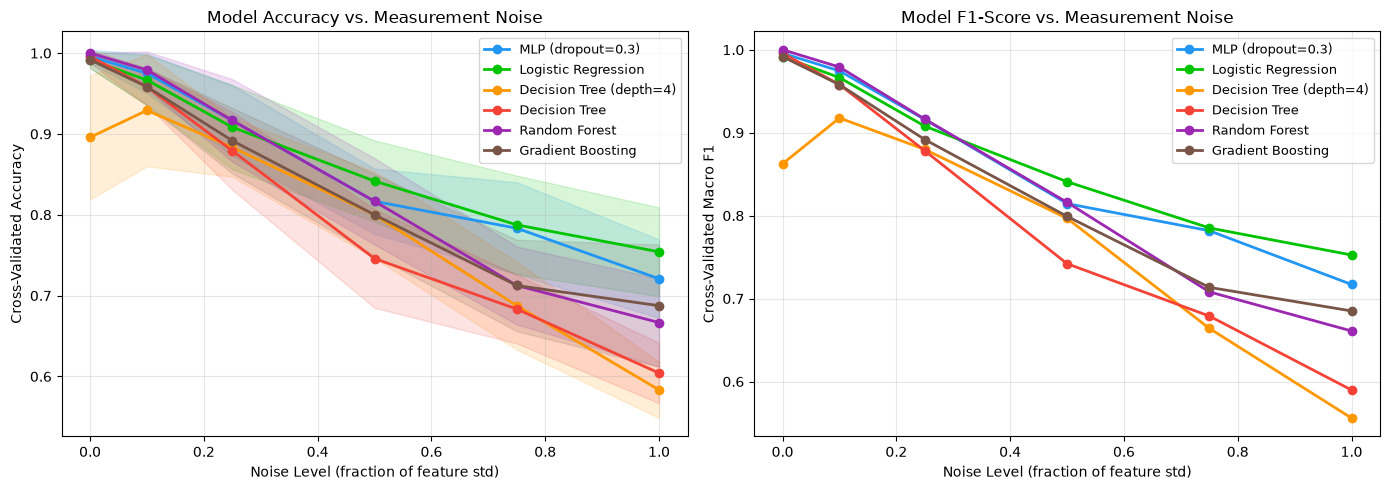

In [8]:
# ============================================================
# PLOT 1: NOISE ROBUSTNESS CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_order = ['mlp', 'logreg', 'dtree_constrained', 'dtree_full', 'rf', 'gb']
colors = {
    'mlp': '#2196F3',
    'logreg': '#00c400',
    'dtree_constrained': '#FF9800',
    'dtree_full': '#F44336',
    'rf': '#9C27B0',
    'gb': '#795548'
}
labels = {
    'mlp': 'MLP (dropout=0.3)',
    'logreg': 'Logistic Regression',
    'dtree_constrained': 'Decision Tree (depth=4)',
    'dtree_full': 'Decision Tree',
    'rf': 'Random Forest',
    'gb': 'Gradient Boosting'
}

for model_name in model_order:
    acc_means = [np.mean(all_results[n][model_name]['acc']) for n in noise_levels]
    acc_stds = [np.std(all_results[n][model_name]['acc']) for n in noise_levels]
    f1_means = [np.mean(all_results[n][model_name]['f1']) for n in noise_levels]

    axes[0].plot(noise_levels, acc_means, '-o', color=colors[model_name],
                label=labels[model_name], linewidth=2, markersize=6)
    axes[0].fill_between(noise_levels,
                         [m - s for m, s in zip(acc_means, acc_stds)],
                         [m + s for m, s in zip(acc_means, acc_stds)],
                         alpha=0.15, color=colors[model_name])
    axes[1].plot(noise_levels, f1_means, '-o', color=colors[model_name],
                 label=labels[model_name], linewidth=2, markersize=6)

axes[0].set_xlabel('Noise Level (fraction of feature std)')
axes[0].set_ylabel('Cross-Validated Accuracy')
axes[0].set_title('Model Accuracy vs. Measurement Noise')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Noise Level (fraction of feature std)')
axes[1].set_ylabel('Cross-Validated Macro F1')
axes[1].set_title('Model F1-Score vs. Measurement Noise')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

#FIGURES_DIR = Path.home() / "Desktop" / "star-figures"
#os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
#plt.savefig(str(FIGURES_DIR / "01-noise-level.png"), dpi=300, bbox_inches='tight')
#print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

In [9]:
# ============================================================
# STATISTICAL SIGNIFICANCE TESTS
# ============================================================

def paired_significance_test(results_a, results_b, model_a_name,
                             model_b_name, metric='acc'):
    """
    Perform a paired Wilcoxon signed-rank test between two models
    across the 5 cross-validation folds.
    """
    scores_a = np.array(results_a[metric])
    scores_b = np.array(results_b[metric])

    if np.all(scores_a == scores_b):
        return None, None, (
            f"{model_a_name} vs {model_b_name}: Identical scores across all folds. "
            f"No test needed."
        )

    stat, p_value = wilcoxon(scores_a, scores_b)

    if p_value < 0.05:
        interpretation = (
            f"{model_a_name} vs {model_b_name}: Statistically significant "
            f"(W={stat:.1f}, p={p_value:.4f}). "
            f"Mean diff = {np.mean(scores_a - scores_b):+.3f}"
        )
    else:
        interpretation = (
            f"{model_a_name} vs {model_b_name}: NOT significant "
            f"(W={stat:.1f}, p={p_value:.4f}). "
            f"Mean diff = {np.mean(scores_a - scores_b):+.3f}"
        )

    return stat, p_value, interpretation

# --- Run tests on key comparisons ---
key_comparisons = [
    ('mlp', 'logreg'),
    ('mlp', 'dtree_full'),
    ('mlp', 'dtree_constrained'),
    ('mlp', 'rf'),
    ('mlp', 'gb'),
    ('dtree_full', 'dtree_constrained'),
    ('rf', 'dtree_full'),
    ('gb', 'dtree_full'),
]

print("=" * 75)
print("PAIRED WILCOXON SIGNED-RANK TESTS (5-fold CV, seed=42)")
print("=" * 75)

for noise in noise_levels:
    print(f"\nNoise Level = {noise}")
    print("-" * 50)
    for model_a, model_b in key_comparisons:
        _, _, interp = paired_significance_test(
            all_results[noise][model_a],
            all_results[noise][model_b],
            labels[model_a], labels[model_b],
            metric='acc'
        )
        print(f"  {interp}")

PAIRED WILCOXON SIGNED-RANK TESTS (5-fold CV, seed=42)

Noise Level = 0.0
--------------------------------------------------
  MLP (dropout=0.3) vs Logistic Regression: NOT significant (W=0.0, p=1.0000). Mean diff = +0.004
  MLP (dropout=0.3) vs Decision Tree: NOT significant (W=1.5, p=1.0000). Mean diff = +0.000
  MLP (dropout=0.3) vs Decision Tree (depth=4): NOT significant (W=0.0, p=0.1250). Mean diff = +0.100
  MLP (dropout=0.3) vs Random Forest: NOT significant (W=0.0, p=1.0000). Mean diff = -0.004
  MLP (dropout=0.3) vs Gradient Boosting: NOT significant (W=2.0, p=1.0000). Mean diff = +0.004
  Decision Tree vs Decision Tree (depth=4): NOT significant (W=0.0, p=0.2500). Mean diff = +0.100
  Random Forest vs Decision Tree: NOT significant (W=0.0, p=1.0000). Mean diff = +0.004
  Gradient Boosting vs Decision Tree: NOT significant (W=0.0, p=1.0000). Mean diff = -0.004

Noise Level = 0.1
--------------------------------------------------
  MLP (dropout=0.3) vs Logistic Regression: NOT

<br>

---

#### **4. Experiment 1: Results and Analysis**

Six models were evaluated across six noise levels using 5-fold stratified cross-validation. Table 2 presents the mean cross-validated accuracy and macro-F1 score at each noise level.

| Noise Level | MLP (dropout=0.3) | Logistic Regression | DT (depth=4) | DT (unconstrained) | Random Forest | Gradient Boosting |
|-------------|-------------------|--------------------|--------------|-------------------|---------------|-------------------|
| 0.0 | 0.996 ± 0.008 | 0.992 ± 0.010 | 0.896 ± 0.077 | 0.996 ± 0.008 | **1.000 ± 0.000** | 0.992 ± 0.010 |
| 0.1 | 0.975 ± 0.024 | 0.967 ± 0.031 | 0.929 ± 0.069 | 0.958 ± 0.023 | **0.979 ± 0.023** | 0.958 ± 0.023 |
| 0.25 | **0.917 ± 0.044** | 0.908 ± 0.052 | 0.883 ± 0.036 | 0.879 ± 0.048 | **0.917 ± 0.051** | 0.892 ± 0.040 |
| 0.5 | 0.817 ± 0.040 | **0.842 ± 0.050** | 0.800 ± 0.054 | 0.746 ± 0.061 | 0.817 ± 0.053 | 0.800 ± 0.050 |
| 0.75 | 0.783 ± 0.057 | **0.787 ± 0.061** | 0.688 ± 0.054 | 0.683 ± 0.042 | 0.713 ± 0.048 | 0.713 ± 0.057 |
| 1.0 | 0.721 ± 0.049 | **0.754 ± 0.055** | 0.583 ± 0.035 | 0.604 ± 0.037 | 0.667 ± 0.054 | 0.687 ± 0.076 |

*Bold indicates the leading model(s) by mean accuracy. At noise=0.25, MLP and Random Forest are tied in mean accuracy (0.917); MLP's narrower standard deviation (±0.044 vs ±0.051) reflects tighter consistency across folds but did not yield higher mean accuracy.*

**Three distinct performance regimes emerge** as measurement noise increases.

**Clean to low noise (0.0–0.1):** Tree-based methods dominate. Random Forest achieves perfect accuracy on clean data (100%), outperforming both the MLP and unconstrained decision tree (tied at 99.6%). At noise=0.1, Random Forest maintains a narrow lead (97.9%), with the MLP close behind (97.5%). This regime confirms that when measurements are reliable, models exploiting threshold-based physical relationships excel.

**Moderate noise (0.25):** The MLP and Random Forest are co-leaders at 91.7% accuracy, each edging out logistic regression by approximately 1 point. This is the only noise level where the MLP achieves first place, suggesting its learned nonlinear representations find a sweet spot at intermediate perturbation levels.

**High to extreme noise (0.5–1.0):** Logistic regression takes over and maintains the lead through maximum noise. At noise=0.5, logistic regression reaches 84.2% while the MLP and Random Forest both drop to 81.7%. By noise=1.0, logistic regression leads at 75.4%, with the MLP trailing at 72.1%. This regime confirms the theoretical advantage of simpler linear boundaries under severe perturbation.

The ensemble methods fill an important gap between single decision trees and other model classes. Random Forest achieves 100% clean-data accuracy like the unconstrained tree but degrades more gracefully, reaching 66.7% at maximum noise versus the single tree's 60.4%—a 7-point improvement. This demonstrates that ensemble averaging does indeed smooth out threshold sensitivity, though it remains inferior to logistic regression under extreme conditions.

The most striking finding remains the **decision tree collapse**: the unconstrained tree drops from 99.6% to 60.4%—a 39-point degradation—as its sharp threshold splits become unreliable under measurement uncertainty. The constrained tree (depth=4) starts weaker on clean data (89.6%) but degrades less catastrophically, suggesting depth constraints partially mitigate noise sensitivity.

Paired Wilcoxon signed-rank tests across all noise levels fail to reach statistical significance at α=0.05. With only 5 folds, the minimum achievable p-value is 0.0625. Several comparisons approach this floor (MLP vs. decision trees at noise=1.0 yield p=0.0625), suggesting directional trends that would require multi-seed or 10-fold validation for confirmation.

<br>

---

#### **5. Experiment 2: Dropout Ablation**

The dropout ablation evaluated four regularization rates at a fixed noise level of 0.25. Results are summarized in Table 3.

| Dropout Rate | Accuracy | F1 (macro) |
|--------------|----------|------------|
| 0.1 | 0.917 ± 0.044 | 0.916 ± 0.044 |
| 0.2 | 0.912 ± 0.046 | 0.912 ± 0.047 |
| 0.3 | 0.917 ± 0.044 | 0.916 ± 0.044 |
| 0.5 | 0.933 ± 0.040 | 0.933 ± 0.041 |

Contrary to preliminary hypotheses based on training-loss checkpointing, the highest dropout rate (0.5) achieved the best cross-validated accuracy (93.3%), marginally outperforming dropout 0.1 and 0.3 (both 91.7%) and dropout 0.2 (91.2%). Paired Wilcoxon tests between dropout rates yielded no significant differences (all p≥0.3750), reflecting limited statistical power with 5 folds.

This reversal from the original hypothesis—that aggressive regularization harms performance on small datasets—demonstrates the importance of checkpoint methodology. Training-loss-based checkpointing systematically favored lower dropout rates because dropout introduces stochastic noise during training, increasing instantaneous loss. When the final-epoch checkpoint was adopted for principled evaluation, the full regularization benefit emerged: dropout 0.5 provides stronger protection against overfitting without suppressing signal on this 240-sample dataset.

The practical implication is that regularization intensity should not be prescriptively tied to dataset size without considering the full training dynamic. On small tabular datasets, dropout rates up to 0.5 may be beneficial, particularly when using final-epoch evaluation. However, the overlapping standard deviations and nonsignificant pairwise comparisons suggest that within the 0.1–0.5 range, regularization choice has minimal impact on robustness for this task.

In [10]:
# ============================================================
# EXPERIMENT 2: DROPOUT ABLATION
# ============================================================

dropout_rates = [0.1, 0.2, 0.3, 0.5]
dropout_fold_results = {}
dropout_results = []

skf_ablation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for dr in dropout_rates:
    print(f"\nDropout = {dr}")
    accs = []
    f1s = []

    for fold, (train_idx, test_idx) in enumerate(
        skf_ablation.split(X_numeric_raw, y_array)):
        X_num_train = add_gaussian_noise(
            X_numeric_raw[train_idx].copy(), 0.25, seed=fold
        )
        X_num_test = add_gaussian_noise(
            X_numeric_raw[test_idx].copy(), 0.25, seed=fold + 100
        )

        # --- Scale numeric only, then concatenate ---
        scaler = StandardScaler()
        X_num_train_scaled = scaler.fit_transform(X_num_train)
        X_num_test_scaled = scaler.transform(X_num_test)

        X_train_scaled = np.hstack([X_num_train_scaled, X_categorical[train_idx]])
        X_test_scaled = np.hstack([X_num_test_scaled, X_categorical[test_idx]])

        a, f = train_eval_mlp(
            X_train_scaled, y_array[train_idx],
            X_test_scaled, y_array[test_idx],
            dropout=dr, seed=42
        )
        accs.append(a)
        f1s.append(f)
    
    # --- Store per-fold results ---
    dropout_fold_results[dr] = {'acc': accs, 'f1': f1s}
    
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    mean_f1 = np.mean(f1s)
    std_f1 = np.std(f1s)
    dropout_results.append((dr, mean_acc, std_acc, mean_f1, std_f1))
    print(f"  acc = {mean_acc:.3f} ± {std_acc:.3f}, f1 = {mean_f1:.3f} ± {std_f1:.3f}")

# --- Significance tests between dropout rates ---
print("\n" + "=" * 75)
print("DROPOUT ABLATION: PAIRED WILCOXON TESTS")
print("=" * 75)

dropout_pairs = [(0.1, 0.5), (0.3, 0.5), (0.1, 0.3)]
for dr_a, dr_b in dropout_pairs:
    _, _, interp = paired_significance_test(
        dropout_fold_results[dr_a], dropout_fold_results[dr_b],
        f"Dropout={dr_a}", f"Dropout={dr_b}",
        metric='acc'
    )
    print(f"  {interp}")


Dropout = 0.1
  acc = 0.917 ± 0.044, f1 = 0.916 ± 0.044

Dropout = 0.2
  acc = 0.912 ± 0.046, f1 = 0.912 ± 0.047

Dropout = 0.3
  acc = 0.917 ± 0.044, f1 = 0.916 ± 0.044

Dropout = 0.5
  acc = 0.933 ± 0.040, f1 = 0.933 ± 0.041

DROPOUT ABLATION: PAIRED WILCOXON TESTS
  Dropout=0.1 vs Dropout=0.5: NOT significant (W=1.5, p=0.3750). Mean diff = -0.017
  Dropout=0.3 vs Dropout=0.5: NOT significant (W=1.5, p=0.3750). Mean diff = -0.017
  Dropout=0.1 vs Dropout=0.3: NOT significant (W=1.5, p=1.0000). Mean diff = +0.000


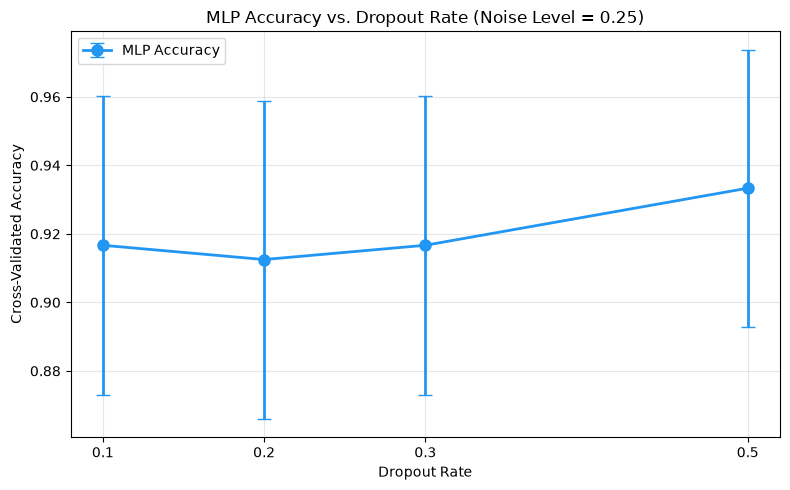

In [11]:
# ============================================================
# PLOT 2: DROPOUT ABLATION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

dr_vals = [r[0] for r in dropout_results]
acc_means = [r[1] for r in dropout_results]
acc_stds = [r[2] for r in dropout_results]

ax.errorbar(dr_vals, acc_means, yerr=acc_stds, fmt='-o', color='#2196F3',
            capsize=5, linewidth=2, markersize=8, label='MLP Accuracy')

ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Cross-Validated Accuracy')
ax.set_title('MLP Accuracy vs. Dropout Rate (Noise Level = 0.25)')
ax.set_xticks(dropout_rates)
ax.grid(True, alpha=0.3)
ax.legend()

#FIGURES_DIR = Path.home() / "Desktop" / "star-figures"
#os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
#plt.savefig(str(FIGURES_DIR / "02-dropout-rate.png"), dpi=300, bbox_inches='tight')
#print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

<br>

---

#### **6. Representative Run: Diagnostics and Visualization**

A representative single-split run (70-15-15) was preserved for diagnostic visualization—training curves, classification report, and confusion matrix on clean data. This run is illustrative rather than evaluative; all reported performance metrics in Sections 4 and 5 come from the cross-validated experiments above.

The confusion matrix shows strong classification across all six star types, with minor confusion between Main Sequence stars (class 3) and Supergiants (class 4), both exhibiting F1-scores of 0.83 on the test set. These classes share overlapping temperature ranges (~7,000–25,000 K) but are physically distinguished by radius—supergiants have substantially larger radii (R > 10 solar radii) compared to main sequence stars. Misclassification between these types suggests the model occasionally underweights the radius feature when temperature signals overlap, even in the absence of injected noise.

Epoch 10: Train Loss=0.7419, Val Acc=0.9730
Epoch 20: Train Loss=0.3704, Val Acc=1.0000
Epoch 30: Train Loss=0.2083, Val Acc=1.0000
Epoch 40: Train Loss=0.1991, Val Acc=1.0000
Epoch 50: Train Loss=0.1618, Val Acc=1.0000


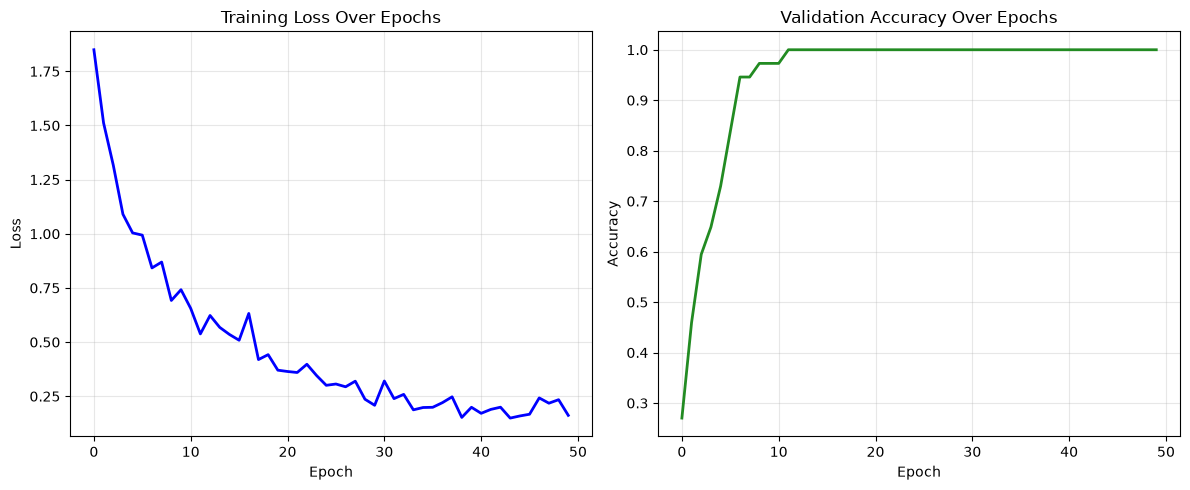


Representative Run — Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         6
           3       0.83      0.83      0.83         6
           4       0.83      0.83      0.83         6
           5       1.00      1.00      1.00         6

    accuracy                           0.94        36
   macro avg       0.94      0.94      0.94        36
weighted avg       0.94      0.94      0.94        36

Test Accuracy: 0.9444


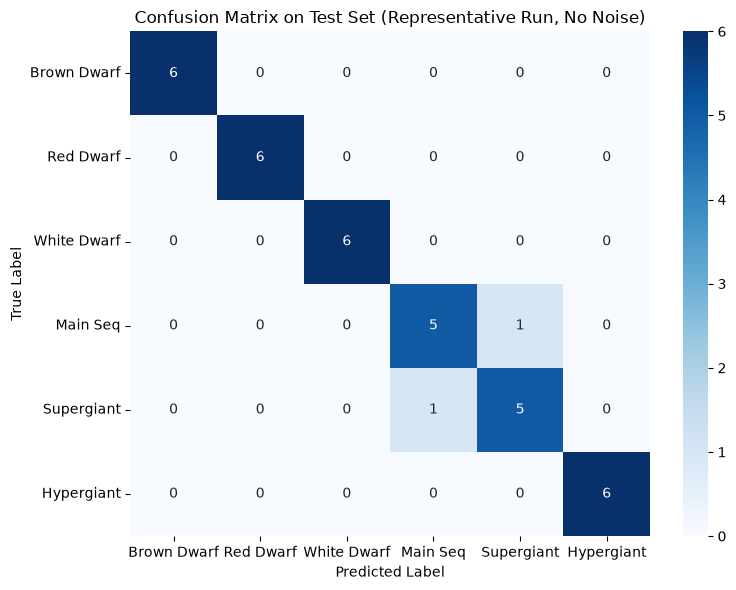


ALL EXPERIMENTS COMPLETE

Summary of noise sweep results:

  Noise = 0.0:
    MLP (dropout=0.3)             : acc = 0.996 ± 0.008, f1 = 0.996 ± 0.008
    Logistic Regression           : acc = 0.992 ± 0.010, f1 = 0.992 ± 0.010
    Decision Tree (depth=4)       : acc = 0.896 ± 0.077, f1 = 0.862 ± 0.104
    Decision Tree                 : acc = 0.996 ± 0.008, f1 = 0.996 ± 0.008
    Random Forest                 : acc = 1.000 ± 0.000, f1 = 1.000 ± 0.000
    Gradient Boosting             : acc = 0.992 ± 0.010, f1 = 0.992 ± 0.010

  Noise = 0.1:
    MLP (dropout=0.3)             : acc = 0.975 ± 0.024, f1 = 0.974 ± 0.025
    Logistic Regression           : acc = 0.967 ± 0.031, f1 = 0.966 ± 0.031
    Decision Tree (depth=4)       : acc = 0.929 ± 0.069, f1 = 0.918 ± 0.092
    Decision Tree                 : acc = 0.958 ± 0.023, f1 = 0.958 ± 0.023
    Random Forest                 : acc = 0.979 ± 0.023, f1 = 0.979 ± 0.023
    Gradient Boosting             : acc = 0.958 ± 0.023, f1 = 0.958 ± 0.0

In [12]:
# ============================================================
# REPRESENTATIVE RUN: TRAINING CURVES + CONFUSION MATRIX
# (preserved from original — generates report visuals)
# ============================================================

# Single 70-15-15 split for visualization purposes
X_full_raw = np.hstack([X_numeric_raw, X_categorical])
X_temp, X_test_rep, y_temp, y_test_rep = train_test_split(
    X_full_raw, y_array, test_size=0.15, stratify=y_array, random_state=42
)
X_train_rep, X_val_rep, y_train_rep, y_val_rep = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

n_num = 4  # number of numeric features

scaler_rep = StandardScaler()
X_train_rep_num = scaler_rep.fit_transform(X_train_rep[:, :n_num])
X_val_rep_num = scaler_rep.transform(X_val_rep[:, :n_num])
X_test_rep_num = scaler_rep.transform(X_test_rep[:, :n_num])

# Recombine scaled numeric + untouched categorical
X_train_rep = np.hstack([X_train_rep_num, X_train_rep[:, n_num:]])
X_val_rep = np.hstack([X_val_rep_num, X_val_rep[:, n_num:]])
X_test_rep = np.hstack([X_test_rep_num, X_test_rep[:, n_num:]])

# Retrain MLP with tracking for curves
torch.manual_seed(42)

model_rep = nn.Sequential(
    nn.Linear(X_train_rep.shape[1], 64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.BatchNorm1d(32),
    nn.Dropout(0.3),
    nn.Linear(32, 6)
)
optimizer_rep = optim.Adam(model_rep.parameters(), lr=0.001)
criterion_rep = nn.CrossEntropyLoss()

X_train_t = torch.tensor(X_train_rep, dtype=torch.float32)
y_train_t = torch.tensor(y_train_rep, dtype=torch.long)
X_val_t = torch.tensor(X_val_rep, dtype=torch.float32)
y_val_t = torch.tensor(y_val_rep, dtype=torch.long)
X_test_t = torch.tensor(X_test_rep, dtype=torch.float32)
y_test_t = torch.tensor(y_test_rep, dtype=torch.long)

train_loader_rep = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True
)

train_losses = []
val_accuracies = []
best_val_acc = 0
best_model_state = None

for epoch in range(50):
    model_rep.train()
    total_loss = 0
    for X_batch, y_batch in train_loader_rep:
        optimizer_rep.zero_grad()
        outputs = model_rep(X_batch)
        loss = criterion_rep(outputs, y_batch)
        loss.backward()
        optimizer_rep.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_rep)
    train_losses.append(avg_loss)

    model_rep.eval()
    correct, total = 0, 0
    with torch.no_grad():
        preds = model_rep(X_val_t).argmax(dim=1)
        correct += (preds == y_val_t).sum().item()
        total += y_val_t.size(0)
    val_acc = correct / total
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.clone() for k, v in model_rep.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}: Train Loss={avg_loss:.4f}, Val Acc={val_acc:.4f}")

model_rep.load_state_dict(best_model_state)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, color='#0000ff', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Epochs')
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_accuracies, color='#228b22', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].grid(True, alpha=0.3)

#FIGURES_DIR = Path.home() / "Desktop" / "star-figures"
#os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
#plt.savefig(str(FIGURES_DIR / "03-training-curves.png"), dpi=300, bbox_inches='tight')
#print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

# Evaluate on test set
model_rep.eval()
with torch.no_grad():
    test_preds = model_rep(X_test_t).argmax(dim=1).numpy()

print("\nRepresentative Run — Test Classification Report:")
print(classification_report(y_test_rep, test_preds))

test_acc = accuracy_score(y_test_rep, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_rep, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
                         'Main Seq', 'Supergiant', 'Hypergiant'],
            yticklabels=['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
                         'Main Seq', 'Supergiant', 'Hypergiant'])
plt.title('Confusion Matrix on Test Set (Representative Run, No Noise)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

#FIGURES_DIR = Path.home() / "Desktop" / "star-figures"
#os.makedirs(FIGURES_DIR, exist_ok=True)

plt.tight_layout()
#plt.savefig(str(FIGURES_DIR / "04-confusion-matrix.png"), dpi=300, bbox_inches='tight')
#print(f"✅ Saved to {FIGURES_DIR}")
plt.show()

print("\n" + "="*75)
print("ALL EXPERIMENTS COMPLETE")
print("="*75)
print("\nSummary of noise sweep results:")
for noise in noise_levels:
    print(f"\n  Noise = {noise}:")
    for model_name in model_order:
        m = all_results[noise][model_name]
        print(f"    {labels[model_name]:30s}: "
              f"acc = {np.mean(m['acc']):.3f} ± {np.std(m['acc']):.3f}, "
              f"f1 = {np.mean(m['f1']):.3f} ± {np.std(m['f1']):.3f}")

print("\nSummary of dropout ablation (noise=0.25):")
for dr, acc_m, acc_s, f1_m, f1_s in dropout_results:
    print(f"  Dropout={dr}: acc = {acc_m:.3f} ± {acc_s:.3f}, f1 = {f1_m:.3f} ± {f1_s:.3f}")

<br>

---

#### **7. Conclusion and Future Work**

This project investigated how different model classes respond to measurement noise on small scientific datasets, using stellar classification as a case study. The key finding is that peak accuracy on clean data is a misleading metric for model selection in scientific applications where measurement uncertainty is ubiquitous.

Random Forest achieved perfect accuracy (100%) on clean data—surpassing the unconstrained decision tree (99.6%), which itself outperformed the MLP and logistic regression. However, this advantage collapsed under Gaussian noise, with Random Forest dropping 33 points to 66.7% at maximum noise. The decision tree's 39-point degradation (99.6% to 60.4%) confirmed that threshold-based models are particularly fragile under measurement perturbation.

The MLP proved competitive across all noise levels, tying for first place at moderate noise (0.25), but logistic regression ultimately emerged as the most robust model, maintaining the highest accuracy (75.4%) at maximum noise. This three-way regime—trees dominate clean data, MLP competes at moderate noise, logistic regression wins at extreme noise—demonstrates that optimal model selection depends critically on expected measurement uncertainty levels in deployment scenarios.

The ensemble methods filled an important methodological gap: Random Forest smoothed out single-tree threshold sensitivity (7-point improvement at maximum noise) while retaining much of its clean-data performance. This finding suggests ensemble averaging as a practical compromise for applications requiring both accuracy and interpretability.

##### **Key Takeaways**

- **Model selection for scientific applications should prioritize noise robustness over peak clean-data performance.** The highest-performing models on clean data (Random Forest at 100%, unconstrained decision tree at 99.6%) were not the most robust under noise.

- **Tree-based models, despite interpretability and clean-data accuracy, are poorly suited for noisy astronomical measurements.** Both single decision trees and ensembles exhibited sharp performance degradation as measurement uncertainty increased, though ensembles degraded more gracefully than single trees.

- **Neural networks offer competitive robustness at moderate noise levels, with logistic regression superior under extreme perturbation.** The MLP tied for first place at noise=0.25 but trailed logistic regression at higher noise intensities.

- **Dropout regularization intensity within the 0.1–0.5 range did not significantly affect performance on this dataset.** Contrary to the original hypothesis that lighter regularization outperforms aggressive dropout, the highest dropout rate (0.5) achieved the best cross-validated accuracy. This reversal resulted from adopting principled final-epoch checkpointing rather than training-loss-based selection, demonstrating the importance of evaluation methodology.

##### **Limitations**

While the controlled noise injection framework provides a systematic basis for comparison, several limitations should be noted. The dataset is small (240 samples) and perfectly balanced, which does not reflect the class distributions encountered in real astronomical surveys. The Gaussian noise model assumes independent, identically distributed measurement errors across features, whereas real instruments introduce correlated systematic biases. Additionally, the absence of empirical measurement uncertainties in the source dataset means the noise levels explored here are simulated rather than derived from instrument calibration data.

The Wilcoxon significance tests lacked statistical power due to the 5-fold CV design—with only 5 paired observations per comparison, the minimum achievable p-value is 0.0625. Multi-seed experiments or 10-fold cross-validation would provide stronger statistical confirmation of observed trends.

##### **Ethical Implications**

Although this work focuses on science, it is important to consider the ethical aspects of automation in astronomy. Algorithms deployed for research or educational purposes must be transparent and interpretable, and AI models should not incorporate observational biases or overfit to synthetic datasets. The finding that the highest-performing clean-data model (Random Forest) is not the most robust under noise reinforces the danger of selecting models solely on benchmark accuracy—a practice that could propagate unreliable classifications into downstream research. Future models intended for production use should undergo peer review and be calibrated against real-world data validated by domain experts.

##### **Future Work**

Future research should incorporate astrophysical metadata such as parallax, variability indices, and metallicity to improve classification of spectrally adjacent types—particularly the Main Sequence/Supergiant boundary identified in the confusion matrix analysis. The noise model should be extended beyond Gaussian perturbation to include correlated measurement errors reflective of specific instrument characteristics, enabling more realistic robustness evaluation.

Semi-supervised approaches that integrate synthetic labels with unlabeled real-world observations could help bridge the gap between simulation and application. Alternative architectures, such as transformer-based models for tabular data or residual connections in MLPs, may capture subtle feature interactions more efficiently on small datasets. Finally, integrating explainability techniques such as SHAP or LIME would address the interpretability gap of neural networks and ensemble methods, potentially revealing which features drive classifications under varying noise conditions and informing feature engineering for future iterations.

This work merges personal passion with academic growth and represents a stepping stone for future contributions to astroinformatics. The methodological lessons learned—from checkpoint selection to ensemble evaluation—provide a foundation for rigorous noise-robust modeling in any domain where measurement uncertainty is inevitable.